<a href="https://colab.research.google.com/github/bihjane/Data-science-and-AI-K-12-teaching-tools/blob/main/Cost_Function_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost Function Visualization Lab
## Comparing MSE vs Cross-Entropy for Classification

**Learning Objectives:**
- Visualize the behavior of MSE and Cross-Entropy cost functions
- Understand why MSE is inappropriate for logistic regression
- Recognize how cross-entropy provides better optimization signals
- Connect mathematical formulas to intuitive understanding

## Part 1: Setup and Imports

First, let's import the necessary libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 2: Define Cost Functions

Let's define the mathematical formulas for both cost functions:

**Mean Squared Error (MSE):**
$$\text{MSE} = (\hat{y} - y)^2$$

**Cross-Entropy Loss:**
$$\text{Cross-Entropy} = -y \log(\hat{y}) - (1-y) \log(1-\hat{y})$$

Where:
- $\hat{y}$ = predicted probability (0 to 1)
- $y$ = actual label (0 or 1)

In [ ]:
def mean_squared_error(y_pred, y_actual):
    """
    Calculate MSE cost for a single prediction.

    Parameters:
    -----------
    y_pred : float
        Predicted probability (0 to 1)
    y_actual : int
        Actual label (0 or 1)

    Returns:
    --------
    float : MSE cost
    """
    return (y_pred - y_actual) ** 2


def cross_entropy_loss(y_pred, y_actual):
    """
    Calculate cross-entropy loss for a single prediction.

    Parameters:
    -----------
    y_pred : float or array
        Predicted probability (0 to 1)
    y_actual : int
        Actual label (0 or 1)

    Returns:
    --------
    float or array : Cross-entropy cost
    """
    if y_actual == 1:
        return -np.log(y_pred)
    else:
        return -np.log(1 - y_pred)


print("Cost functions defined!")
print("\nExample calculations:")
print(f"MSE when predicting 0.8 for actual=1: {mean_squared_error(0.8, 1):.4f}")
print(f"Cross-Entropy when predicting 0.8 for actual=1: {cross_entropy_loss(0.8, 1):.4f}")

Cost functions defined!

Example calculations:
MSE when predicting 0.8 for actual=1: 0.0400
Cross-Entropy when predicting 0.8 for actual=1: 0.2231


## Part 3: Generate Predictions

Let's create a range of predicted probabilities from 0.01 to 0.99 to see how the cost functions behave across all possible predictions.

In [ ]:
# Generate predicted probabilities
# We avoid exact 0 and 1 because log(0) is undefined
predictions = np.linspace(0.01, 0.99, 200)

print(f"Generated {len(predictions)} prediction values")
print(f"Range: {predictions.min():.2f} to {predictions.max():.2f}")

Generated 200 prediction values
Range: 0.01 to 0.99


## Part 4: Calculate Costs for Different Scenarios

We'll calculate costs for two scenarios:
1. **Actual = 1** (passenger survived)
2. **Actual = 0** (passenger did not survive)

In [ ]:
# Scenario 1: Actual = 1 (survived)
mse_survived = mean_squared_error(predictions, 1)
cross_entropy_survived = cross_entropy_loss(predictions, 1)

# Scenario 2: Actual = 0 (did not survive)
mse_not_survived = mean_squared_error(predictions, 0)
cross_entropy_not_survived = cross_entropy_loss(predictions, 0)

print("Costs calculated for both scenarios!")
print(f"\nFor a confident correct prediction (0.95 when actual=1):")
print(f"  MSE: {mean_squared_error(0.95, 1):.4f}")
print(f"  Cross-Entropy: {cross_entropy_loss(0.95, 1):.4f}")

print(f"\nFor a confident WRONG prediction (0.05 when actual=1):")
print(f"  MSE: {mean_squared_error(0.05, 1):.4f}")
print(f"  Cross-Entropy: {cross_entropy_loss(0.05, 1):.4f}")

Costs calculated for both scenarios!

For a confident correct prediction (0.95 when actual=1):
  MSE: 0.0025
  Cross-Entropy: 0.0513

For a confident WRONG prediction (0.05 when actual=1):
  MSE: 0.9025
  Cross-Entropy: 2.9957


## Part 5: Visualize Cost Functions

Now let's create visualizations to compare the behavior of both cost functions.

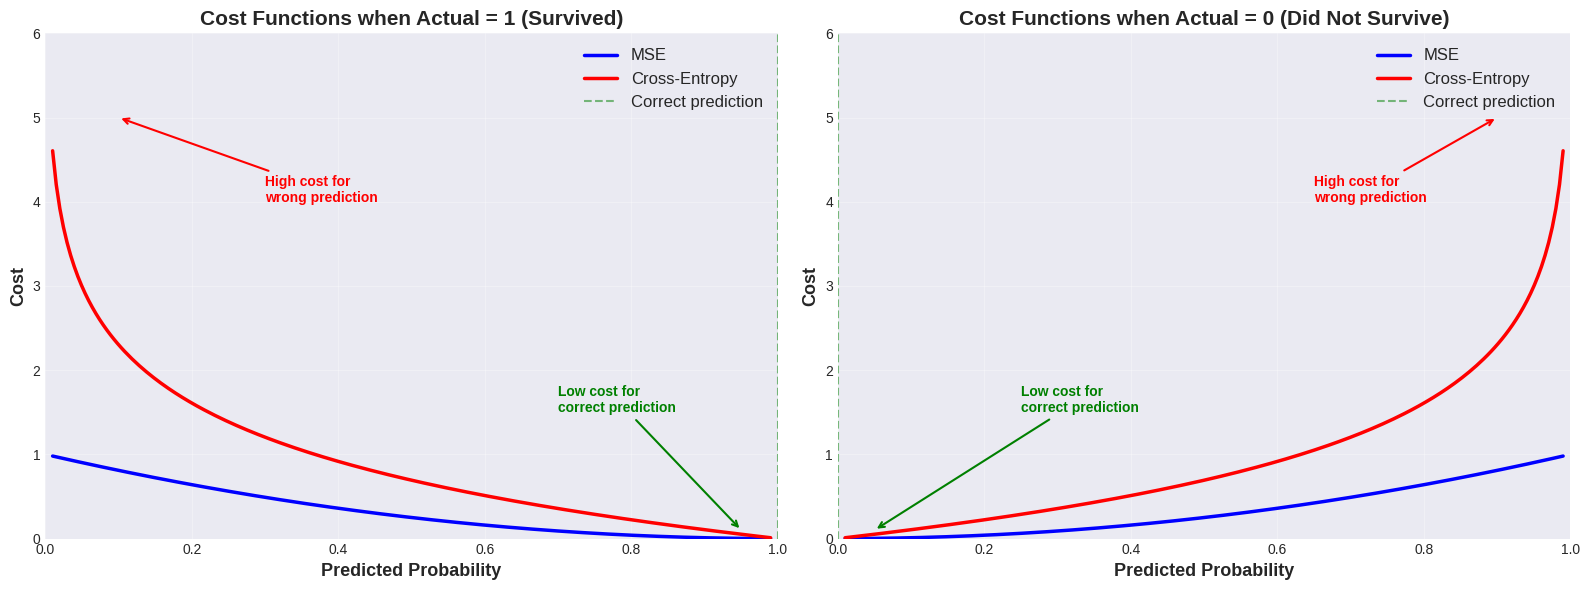

Visualization complete!


In [ ]:
# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: When Actual = 1 (Survived)
axes[0].plot(predictions, mse_survived, 'b-', label='MSE', linewidth=2.5)
axes[0].plot(predictions, cross_entropy_survived, 'r-', label='Cross-Entropy', linewidth=2.5)
axes[0].axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Correct prediction')
axes[0].set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cost', fontsize=13, fontweight='bold')
axes[0].set_title('Cost Functions when Actual = 1 (Survived)', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 6])
axes[0].set_xlim([0, 1])

# Add annotations for key points
axes[0].annotate('Low cost for\ncorrect prediction',
                xy=(0.95, 0.1), xytext=(0.7, 1.5),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                fontsize=10, color='green', fontweight='bold')

axes[0].annotate('High cost for\nwrong prediction',
                xy=(0.1, 5), xytext=(0.3, 4),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red', fontweight='bold')

# Plot 2: When Actual = 0 (Did Not Survive)
axes[1].plot(predictions, mse_not_survived, 'b-', label='MSE', linewidth=2.5)
axes[1].plot(predictions, cross_entropy_not_survived, 'r-', label='Cross-Entropy', linewidth=2.5)
axes[1].axvline(x=0.0, color='green', linestyle='--', alpha=0.5, label='Correct prediction')
axes[1].set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cost', fontsize=13, fontweight='bold')
axes[1].set_title('Cost Functions when Actual = 0 (Did Not Survive)', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 6])
axes[1].set_xlim([0, 1])

# Add annotations for key points
axes[1].annotate('Low cost for\ncorrect prediction',
                xy=(0.05, 0.1), xytext=(0.25, 1.5),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                fontsize=10, color='green', fontweight='bold')

axes[1].annotate('High cost for\nwrong prediction',
                xy=(0.9, 5), xytext=(0.65, 4),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Part 6: Detailed Analysis - The Problem with MSE

Let's focus on why MSE is problematic for classification.

In [ ]:
# Calculate costs at key prediction values
test_predictions = [0.1, 0.3, 0.5, 0.7, 0.9]

print("="*70)
print("COST COMPARISON FOR ACTUAL = 1 (SURVIVED)")
print("="*70)
print(f"{'Prediction':<15} {'MSE':<15} {'Cross-Entropy':<15} {'CE/MSE Ratio':<15}")
print("-"*70)

for pred in test_predictions:
    mse = mean_squared_error(pred, 1)
    ce = cross_entropy_loss(pred, 1)
    ratio = ce / mse if mse > 0 else float('inf')
    print(f"{pred:<15.1f} {mse:<15.4f} {ce:<15.4f} {ratio:<15.2f}")

print("\n" + "="*70)
print("KEY OBSERVATIONS:")
print("="*70)
print("1. MSE at 0.5 prediction: Same cost (0.25) for BOTH classes!")
print("   → Model gets NO signal about which direction to move")
print("\n2. MSE grows slowly for wrong predictions")
print("   → Weak penalty for being confidently wrong")
print("\n3. Cross-Entropy explodes for wrong predictions")
print("   → Strong penalty drives model away from wrong answers")
print("\n4. Cross-Entropy is asymmetric")
print("   → Different behavior for different classes provides clear gradients")

COST COMPARISON FOR ACTUAL = 1 (SURVIVED)
Prediction      MSE             Cross-Entropy   CE/MSE Ratio   
----------------------------------------------------------------------
0.1             0.8100          2.3026          2.84           
0.3             0.4900          1.2040          2.46           
0.5             0.2500          0.6931          2.77           
0.7             0.0900          0.3567          3.96           
0.9             0.0100          0.1054          10.54          

KEY OBSERVATIONS:
1. MSE at 0.5 prediction: Same cost (0.25) for BOTH classes!
   → Model gets NO signal about which direction to move

2. MSE grows slowly for wrong predictions
   → Weak penalty for being confidently wrong

3. Cross-Entropy explodes for wrong predictions
   → Strong penalty drives model away from wrong answers

4. Cross-Entropy is asymmetric
   → Different behavior for different classes provides clear gradients


## Part 7: Gradient Analysis

Let's visualize why cross-entropy provides better optimization signals by looking at the gradients (slopes).

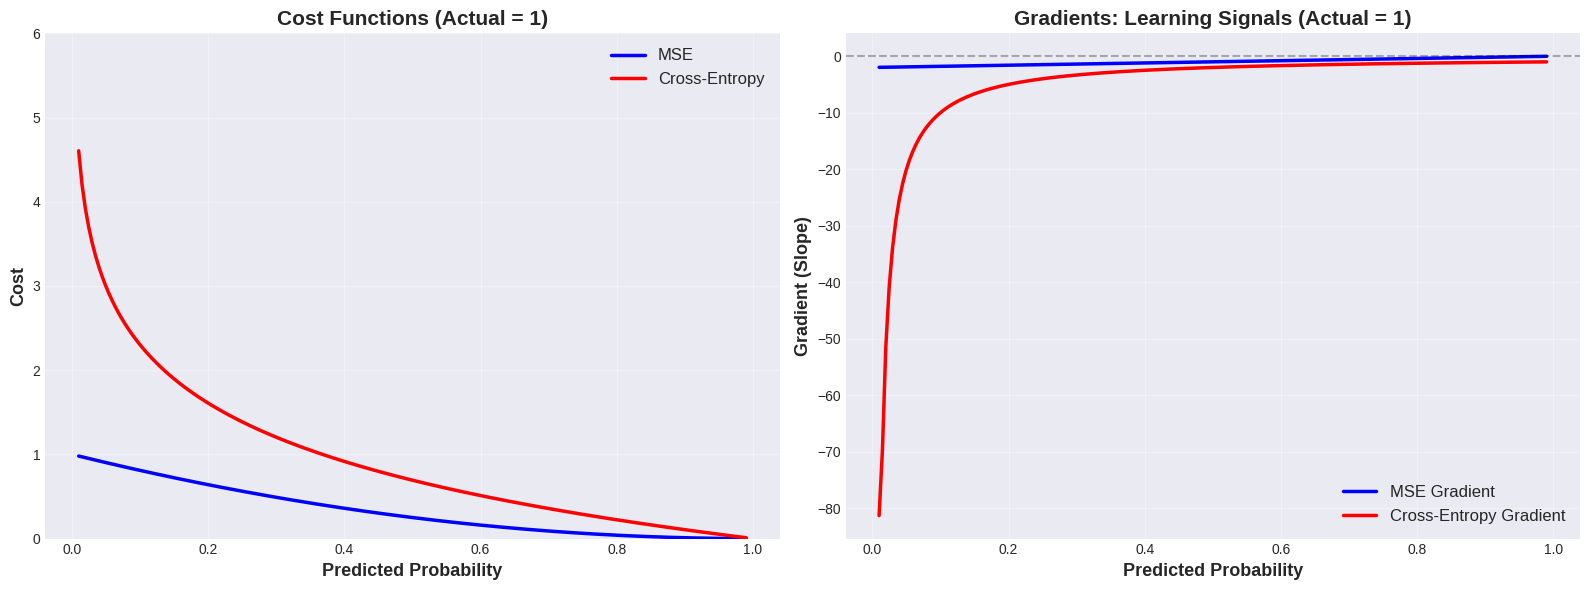


Gradient Analysis:
- Steeper gradient = Stronger learning signal
- Cross-entropy provides much stronger gradients when predictions are wrong
- This helps gradient descent converge faster and more reliably


In [ ]:
# Calculate gradients (derivatives) numerically
def calculate_gradient(costs, predictions):
    """Calculate gradient using numerical differentiation"""
    gradient = np.gradient(costs, predictions)
    return gradient

# Calculate gradients for actual = 1
mse_gradient = calculate_gradient(mse_survived, predictions)
ce_gradient = calculate_gradient(cross_entropy_survived, predictions)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cost Functions
axes[0].plot(predictions, mse_survived, 'b-', label='MSE', linewidth=2.5)
axes[0].plot(predictions, cross_entropy_survived, 'r-', label='Cross-Entropy', linewidth=2.5)
axes[0].set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cost', fontsize=13, fontweight='bold')
axes[0].set_title('Cost Functions (Actual = 1)', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 6])

# Plot 2: Gradients
axes[1].plot(predictions, mse_gradient, 'b-', label='MSE Gradient', linewidth=2.5)
axes[1].plot(predictions, ce_gradient, 'r-', label='Cross-Entropy Gradient', linewidth=2.5)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gradient (Slope)', fontsize=13, fontweight='bold')
axes[1].set_title('Gradients: Learning Signals (Actual = 1)', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGradient Analysis:")
print("- Steeper gradient = Stronger learning signal")
print("- Cross-entropy provides much stronger gradients when predictions are wrong")
print("- This helps gradient descent converge faster and more reliably")

## Part 8: Discussion Questions

**Answer these questions based on the visualizations above:**

1. **What happens to MSE cost when prediction = 0.5 for both classes (actual=0 and actual=1)?**
   - Your answer:

2. **How does cross-entropy penalize confident wrong predictions compared to MSE?**
   - Your answer:

3. **Why is cross-entropy's behavior better for gradient descent optimization?**
   - Your answer:

4. **What would happen if you tried to train a logistic regression model with MSE?**
   - Your answer:

5. **In the Titanic dataset context, why is it important to heavily penalize wrong predictions?**
   - Your answer:

## Part 9: Real-World Connection

Let's think about this in the context of the Titanic dataset.

In [ ]:
print("="*70)
print("TITANIC SURVIVAL PREDICTION SCENARIOS")
print("="*70)

scenarios = [
    ("First-class female", 0.95, 1, "Correctly predicts survival"),
    ("Third-class male", 0.15, 0, "Correctly predicts death"),
    ("Second-class child", 0.60, 1, "Uncertain, leans toward survival"),
    ("Elderly third-class male", 0.05, 1, "WRONG: Predicts death, actually survived"),
]

print(f"\n{'Passenger Type':<25} {'Prediction':<12} {'Actual':<8} {'MSE':<10} {'Cross-Ent':<12}")
print("-"*70)

for passenger_type, pred, actual, description in scenarios:
    mse = mean_squared_error(pred, actual)
    ce = cross_entropy_loss(pred, actual)
    print(f"{passenger_type:<25} {pred:<12.2f} {actual:<8} {mse:<10.4f} {ce:<12.4f}")
    print(f"  → {description}")
    print()

print("\nKey Insight:")
print("The last scenario shows why cross-entropy is crucial:")
print("When the model is confidently WRONG, cross-entropy cost is very high (2.9957)")
print("This strong penalty forces the model to reconsider its weights.")
print("MSE only gives a moderate penalty (0.9025), providing weaker learning signal.")

TITANIC SURVIVAL PREDICTION SCENARIOS

Passenger Type            Prediction   Actual   MSE        Cross-Ent   
----------------------------------------------------------------------
First-class female        0.95         1        0.0025     0.0513      
  → Correctly predicts survival

Third-class male          0.15         0        0.0225     0.1625      
  → Correctly predicts death

Second-class child        0.60         1        0.1600     0.5108      
  → Uncertain, leans toward survival

Elderly third-class male  0.05         1        0.9025     2.9957      
  → WRONG: Predicts death, actually survived


Key Insight:
The last scenario shows why cross-entropy is crucial:
When the model is confidently WRONG, cross-entropy cost is very high (2.9957)
This strong penalty forces the model to reconsider its weights.
MSE only gives a moderate penalty (0.9025), providing weaker learning signal.


## Part 10: Summary and Key Takeaways

In [ ]:
print("="*70)
print("KEY TAKEAWAYS: Why Cross-Entropy is Better for Classification")
print("="*70)

takeaways = [
    "1. PROBLEM WITH MSE:",
    "   • Gives same cost (0.25) for predicting 0.5 regardless of actual class",
    "   • Provides weak gradients when predictions are wrong",
    "   • Can create non-convex optimization landscapes with local minima",
    "",
    "2. ADVANTAGES OF CROSS-ENTROPY:",
    "   • Heavily penalizes confident wrong predictions (cost → infinity)",
    "   • Gives low cost for confident correct predictions",
    "   • Provides strong, clear gradients for optimization",
    "   • Creates convex optimization landscape (single global minimum)",
    "",
    "3. MATHEMATICAL FOUNDATION:",
    "   • Cross-entropy comes from maximum likelihood estimation",
    "   • Naturally matches the probabilistic output of sigmoid function",
    "   • Has well-defined derivatives that work well with gradient descent",
    "",
    "4. PRACTICAL IMPACT:",
    "   • Faster training convergence",
    "   • More reliable optimization (no local minima problems)",
    "   • Better final model performance",
    "",
    "5. REMEMBER:",
    "   • Use MSE for regression (continuous outputs)",
    "   • Use Cross-Entropy for classification (probability outputs)",
    "   • The choice of cost function affects both training and final performance",
]

for line in takeaways:
    print(line)

print("\n" + "="*70)

KEY TAKEAWAYS: Why Cross-Entropy is Better for Classification
1. PROBLEM WITH MSE:
   • Gives same cost (0.25) for predicting 0.5 regardless of actual class
   • Provides weak gradients when predictions are wrong
   • Can create non-convex optimization landscapes with local minima

2. ADVANTAGES OF CROSS-ENTROPY:
   • Heavily penalizes confident wrong predictions (cost → infinity)
   • Gives low cost for confident correct predictions
   • Provides strong, clear gradients for optimization
   • Creates convex optimization landscape (single global minimum)

3. MATHEMATICAL FOUNDATION:
   • Cross-entropy comes from maximum likelihood estimation
   • Naturally matches the probabilistic output of sigmoid function
   • Has well-defined derivatives that work well with gradient descent

4. PRACTICAL IMPACT:
   • Faster training convergence
   • More reliable optimization (no local minima problems)
   • Better final model performance

5. REMEMBER:
   • Use MSE for regression (continuous outputs)

## Extension Activity (Optional)

Try modifying the code above to:
1. Create a 3D surface plot showing cost as a function of both prediction and actual value
2. Animate how gradient descent would move through the cost landscape
3. Compare cost functions for multi-class classification (softmax + categorical cross-entropy)
4. Implement your own simple gradient descent to minimize both cost functions

---

## Submission

**When you're done:**
1. Run all cells from top to bottom (Cell → Run All)
2. Answer the discussion questions in Part 8
3. Save your notebook
4. Be prepared to discuss your observations with the class

**Next Steps:**
Now that you understand why cross-entropy is the right cost function for logistic regression, you're ready to implement a complete classification pipeline using scikit-learn!